

# Imports



In [1]:
import pvlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PV Class and important functions

In [2]:
# Class
import pvlib

class PVPark:
    def __init__(self, name, latitude, longitude, altitude, tz, tilt, azimuth, nominal_capacity):
        self.location = pvlib.location.Location(latitude=latitude, longitude=longitude, altitude=altitude, tz=tz, name=name)
        self.tilt = tilt
        self.azimuth = azimuth
        self.nominal_capacity = nominal_capacity

    @classmethod
    def from_dataframe(cls, df, index=0):
        row = df.iloc[index]

        lat = row['latitude']
        azimuth = row['azimuth'] if pd.notnull(row['azimuth']) else 180.0
        tilt = row['tilt'] if pd.notnull(row['tilt']) else lat
        altitude = row['altitude'] if pd.notnull(row['altitude']) else None

        return cls(
            name=row['name'],
            latitude=lat,
            longitude=row['longitude'],
            altitude=altitude,
            tz=row['tz'],
            tilt=tilt,
            azimuth=azimuth,
            nominal_capacity=row['nominal_capacity']
        )

In [3]:
def get_solar_position(df, park):
    # Full time index in local time with timezone
    times = pd.to_datetime(df['collect_time']).dt.tz_localize(park.location.tz, ambiguous=False, nonexistent='NaT')

    # Get solar position
    solpos = park.location.get_solarposition(times)

    # Reset Index
    solpos['collect_time'] = solpos.index
    solpos = solpos.reset_index(drop=True)

    # Reset time to naive
    solpos['collect_time'] = solpos['collect_time'].dt.tz_localize(None)
    solpos = solpos.drop_duplicates(subset='collect_time')

    # Keep columns and calculate cos_zenith
    solpos = solpos[['collect_time', 'azimuth', 'zenith']]
    solpos = solpos.rename(columns={'azimuth': 'solar_azimuth', 'zenith': 'solar_zenith'})
    solpos['cos_zenith'] = np.clip(np.cos(np.radians(solpos['solar_zenith'])), 0, 1)

    # Merge the dataframes
    df['collect_time'] = pd.to_datetime(df['collect_time'])
    df = pd.merge(df, solpos, how='left', on='collect_time')
    df = df.interpolate(method='linear')

    return df

In [4]:
def estimate_dhi_dni(df, park):

    ghi = df['irradiance'].astype(np.float32).values
    ghi = pd.Series(ghi, index=df['collect_time'])

    zenith = df['solar_zenith'].astype(np.float32).values
    zenith = pd.Series(zenith, index=df['collect_time'])

    # Compute DHI and DNI using the Erbs model
    dhi_dni = pvlib.irradiance.erbs(ghi, zenith, ghi.index)[['dhi', 'dni']]

    # Reset index
    dhi_dni['collect_time']=dhi_dni.index
    dhi_dni = dhi_dni.reset_index(drop=True)

    # Merge the dataframes
    df = pd.merge(df, dhi_dni, how='left', on='collect_time')

    return df

In [5]:
def get_poa(df, park):
    # Full time index in global time
    new_df = df.set_index('collect_time')

    # Calculate POA for all time steps
    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=park.tilt,
        surface_azimuth=park.azimuth,
        dni=new_df['dni'],
        ghi=new_df['irradiance'],
        dhi=new_df['dhi'],
        solar_zenith=new_df['solar_zenith'],
        solar_azimuth=new_df['solar_azimuth']
    )

    # Mask nighttime: set poa_global to 0 when sun is below horizon
    poa.loc[new_df['solar_zenith'] >= 90, ['poa_global', 'poa_direct', 'poa_diffuse']] = 0
    poa_global = poa[['poa_global']]

    # Reset Index
    poa_global['collect_time']=poa_global.index
    poa_global = poa_global.reset_index(drop=True)

    print(poa_global)

    # Merge the dataframes
    df = pd.merge(df, poa_global, how='left', on='collect_time')

    return df

In [6]:
def calc_aoi(df, park):
    df['aoi'] = pvlib.irradiance.aoi(
        surface_tilt=park.tilt,
        surface_azimuth=park.azimuth,
        solar_zenith=df['solar_zenith'],
        solar_azimuth=df['solar_azimuth']
    )
    df['cos_aoi'] = np.clip(np.cos(np.radians(df['aoi'])), 0, 1)

    return(df)

In [7]:
def scale_active_power(df, pv_park):
    # Scale and clip the target at 1.0
    df['active_power'] = (df['active_power'] / pv_park.nominal_capacity)
    df['active_power'] = df['active_power'].clip(upper=1.0)
    return df

In [8]:
def add_sin_cos_time(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Ensure datetime
    df["collect_time"] = pd.to_datetime(df["collect_time"])

    # Add minute of day
    df["minute_of_day"] = df["collect_time"].dt.hour * 60 + df["collect_time"].dt.minute

    # Cyclical encodings
    df["sin_time"] = np.sin(2 * np.pi * df["minute_of_day"] / 1440)
    df["cos_time"] = np.cos(2 * np.pi * df["minute_of_day"] / 1440)

    return df

In [9]:
def print_correlations(df):
    df_corr = df.corr()
    abs_corr = df_corr['active_power'].abs().sort_values(ascending=False)
    print(abs_corr)

In [10]:
def clean_and_reorder_df(df: pd.DataFrame, ordered_cols) -> pd.DataFrame:
    df = df.copy()

    # Only keep and reorder the relevant columns
    df = df[ordered_cols]

    return df

# Load  Training Data

## Load metadata and create park info

In [11]:
base_dir="/home/ubuntu/work/data"
park_name="Sarafali-CN506"
weather_source= "station"
feature_type= "processed"

In [12]:
df = pd.read_csv(f"{base_dir}/{park_name}/metadata.csv")
# Create PVPark instance from DataFrame
pv_park = PVPark.from_dataframe(df)
print(pv_park.location)
print(pv_park.tilt)
print(pv_park.azimuth)
print(pv_park.nominal_capacity)

Location: 
  name: Sarafali-CN506
  latitude: 35.13
  longitude: 25.259
  altitude: 334.0
  tz: Europe/Athens
20.0
180.0
1000.0


## Load unprocessed data

In [15]:
df = pd.read_csv(f"{base_dir}/{park_name}/{feature_type}/{weather_source}/data.csv")

print(df.head())
print(len(df)/288)

          collect_time  temperature  irradiance  wind_speed  active_power
0  2023-09-01 00:00:00         22.3         0.0         4.2           0.0
1  2023-09-01 00:05:00         23.1         0.0         5.0           0.0
2  2023-09-01 00:10:00         22.8         0.0         2.1           0.0
3  2023-09-01 00:15:00         22.4         0.0         3.4           0.0
4  2023-09-01 00:20:00         22.2         0.0         3.8           0.0
182.0


## Feature Extraction

### Calculate solar posistion

In [16]:
df = get_solar_position(df, pv_park)

print(df.head())

         collect_time  temperature  irradiance  wind_speed  active_power  \
0 2023-09-01 00:00:00         22.3         0.0         4.2           0.0   
1 2023-09-01 00:05:00         23.1         0.0         5.0           0.0   
2 2023-09-01 00:10:00         22.8         0.0         2.1           0.0   
3 2023-09-01 00:15:00         22.4         0.0         3.4           0.0   
4 2023-09-01 00:20:00         22.2         0.0         3.8           0.0   

   solar_azimuth  solar_zenith  cos_zenith  
0     332.940219    132.533876         0.0  
1     334.506905    132.987727         0.0  
2     336.098200    133.416152         0.0  
3     337.713332    133.818429         0.0  
4     339.351388    134.193853         0.0  


### Estimate dhi & dni

In [17]:
df = estimate_dhi_dni(df, pv_park)

print(df.head())

         collect_time  temperature  irradiance  wind_speed  active_power  \
0 2023-09-01 00:00:00         22.3         0.0         4.2           0.0   
1 2023-09-01 00:05:00         23.1         0.0         5.0           0.0   
2 2023-09-01 00:10:00         22.8         0.0         2.1           0.0   
3 2023-09-01 00:15:00         22.4         0.0         3.4           0.0   
4 2023-09-01 00:20:00         22.2         0.0         3.8           0.0   

   solar_azimuth  solar_zenith  cos_zenith  dhi  dni  
0     332.940219    132.533876         0.0  0.0  0.0  
1     334.506905    132.987727         0.0  0.0  0.0  
2     336.098200    133.416152         0.0  0.0  0.0  
3     337.713332    133.818429         0.0  0.0  0.0  
4     339.351388    134.193853         0.0  0.0  0.0  


### Calculate Poa Global

In [18]:
df = get_poa(df, pv_park)

print(df.head())

       poa_global        collect_time
0             0.0 2023-09-01 00:00:00
1             0.0 2023-09-01 00:05:00
2             0.0 2023-09-01 00:10:00
3             0.0 2023-09-01 00:15:00
4             0.0 2023-09-01 00:20:00
...           ...                 ...
52411         0.0 2024-02-29 23:35:00
52412         0.0 2024-02-29 23:40:00
52413         0.0 2024-02-29 23:45:00
52414         0.0 2024-02-29 23:50:00
52415         0.0 2024-02-29 23:55:00

[52416 rows x 2 columns]
         collect_time  temperature  irradiance  wind_speed  active_power  \
0 2023-09-01 00:00:00         22.3         0.0         4.2           0.0   
1 2023-09-01 00:05:00         23.1         0.0         5.0           0.0   
2 2023-09-01 00:10:00         22.8         0.0         2.1           0.0   
3 2023-09-01 00:15:00         22.4         0.0         3.4           0.0   
4 2023-09-01 00:20:00         22.2         0.0         3.8           0.0   

   solar_azimuth  solar_zenith  cos_zenith  dhi  dni  poa_glo

/tmp/ipykernel_1501/3524025885.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poa_global['collect_time']=poa_global.index


### Calculate Angle of Incidence

In [19]:
df = calc_aoi(df, pv_park)

print(df.head())

         collect_time  temperature  irradiance  wind_speed  active_power  \
0 2023-09-01 00:00:00         22.3         0.0         4.2           0.0   
1 2023-09-01 00:05:00         23.1         0.0         5.0           0.0   
2 2023-09-01 00:10:00         22.8         0.0         2.1           0.0   
3 2023-09-01 00:15:00         22.4         0.0         3.4           0.0   
4 2023-09-01 00:20:00         22.2         0.0         3.8           0.0   

   solar_azimuth  solar_zenith  cos_zenith  dhi  dni  poa_global         aoi  \
0     332.940219    132.533876         0.0  0.0  0.0         0.0  149.282342   
1     334.506905    132.987727         0.0  0.0  0.0         0.0  150.060201   
2     336.098200    133.416152         0.0  0.0  0.0         0.0  150.806191   
3     337.713332    133.818429         0.0  0.0  0.0         0.0  151.517804   
4     339.351388    134.193853         0.0  0.0  0.0         0.0  152.192398   

   cos_aoi  
0      0.0  
1      0.0  
2      0.0  
3      0.0

### Add sin and cos of time


In [20]:
df = add_sin_cos_time(df)

print(df.head())

         collect_time  temperature  irradiance  wind_speed  active_power  \
0 2023-09-01 00:00:00         22.3         0.0         4.2           0.0   
1 2023-09-01 00:05:00         23.1         0.0         5.0           0.0   
2 2023-09-01 00:10:00         22.8         0.0         2.1           0.0   
3 2023-09-01 00:15:00         22.4         0.0         3.4           0.0   
4 2023-09-01 00:20:00         22.2         0.0         3.8           0.0   

   solar_azimuth  solar_zenith  cos_zenith  dhi  dni  poa_global         aoi  \
0     332.940219    132.533876         0.0  0.0  0.0         0.0  149.282342   
1     334.506905    132.987727         0.0  0.0  0.0         0.0  150.060201   
2     336.098200    133.416152         0.0  0.0  0.0         0.0  150.806191   
3     337.713332    133.818429         0.0  0.0  0.0         0.0  151.517804   
4     339.351388    134.193853         0.0  0.0  0.0         0.0  152.192398   

   cos_aoi  minute_of_day  sin_time  cos_time  
0      0.0    

## Calculate Correlation

From the values above we keep:
    active_power(target)
    irradiance
    poa_global
    cos_zenith
    cos_aoi
    dni
    dhi
    cos_time
    temperature
    wind_speed

We drop:
    aoi(redundant, beacause of cos_aoi)
    solar_zenith(redundant, because of cos_zenith)
    sin_time(reduntant, beacause 0f cos_time)
    minute_of_day(low correlation)
    solar_azimuth(low correlation)
    collect_time(low correlation)

### Clean and Reorder Dataframe

In [21]:
# Columns to keep and reorder
ordered_cols = [
        "active_power", "irradiance", "poa_global", "cos_aoi", 
        "dni", "dhi", "cos_time", "temperature", "wind_speed"
]
elastic_df = clean_and_reorder_df(df, ordered_cols)

X = elastic_df.drop(columns=["active_power"])
y = elastic_df["active_power"]

print(df.head())
print(len(df)/48)

         collect_time  temperature  irradiance  wind_speed  active_power  \
0 2023-09-01 00:00:00         22.3         0.0         4.2           0.0   
1 2023-09-01 00:05:00         23.1         0.0         5.0           0.0   
2 2023-09-01 00:10:00         22.8         0.0         2.1           0.0   
3 2023-09-01 00:15:00         22.4         0.0         3.4           0.0   
4 2023-09-01 00:20:00         22.2         0.0         3.8           0.0   

   solar_azimuth  solar_zenith  cos_zenith  dhi  dni  poa_global         aoi  \
0     332.940219    132.533876         0.0  0.0  0.0         0.0  149.282342   
1     334.506905    132.987727         0.0  0.0  0.0         0.0  150.060201   
2     336.098200    133.416152         0.0  0.0  0.0         0.0  150.806191   
3     337.713332    133.818429         0.0  0.0  0.0         0.0  151.517804   
4     339.351388    134.193853         0.0  0.0  0.0         0.0  152.192398   

   cos_aoi  minute_of_day  sin_time  cos_time  
0      0.0    

### Correlations with the Target

In [22]:
print_correlations(elastic_df)

active_power    1.000000
irradiance      0.988421
poa_global      0.979846
dni             0.888882
cos_aoi         0.848350
dhi             0.737467
cos_time        0.711504
temperature     0.442034
wind_speed      0.253056
Name: active_power, dtype: float64


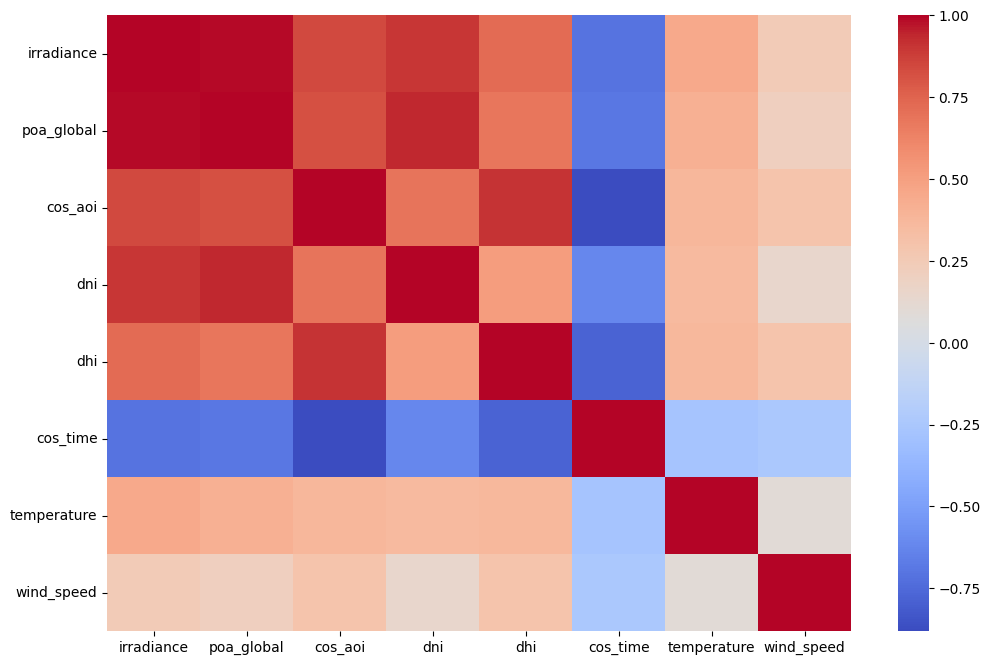

In [23]:
# Assume df is your dataset (without target column)
corr_matrix = X.corr()

# Show correlation heatmap (optional, if using matplotlib/seaborn)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.show()


### Compute Feature Correlation Matrix

In [24]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from sklearn.linear_model import ElasticNetCV

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("enet", ElasticNetCV(l1_ratio=[0.2, 0.5, 0.8, 1.0],  # 1.0 == Lasso
                          cv=KFold(n_splits=5, shuffle=True, random_state=42),
                          n_jobs=-1, random_state=42))
])
pipe.fit(X, y)
enet = pipe.named_steps["enet"]
pd.Series(enet.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)


irradiance     237.410122
dhi             16.050920
poa_global       7.920045
dni              6.801271
wind_speed       1.982198
temperature     -1.766495
cos_time         1.229749
cos_aoi         -0.000000
dtype: float64

In [26]:
# Columns to keep and reorder
ordered_cols = [
        "collect_time", "active_power", "irradiance", "poa_global", "cos_aoi", "dni", "dhi", "temperature", "cos_time"
]
df = clean_and_reorder_df(df, ordered_cols)

print(df.head())
print(len(df)/288)

df.to_csv(f"{base_dir}/{park_name}/feature-engineered/{weather_source}/data.csv", index=False)

         collect_time  active_power  irradiance  poa_global  cos_aoi  dni  \
0 2023-09-01 00:00:00           0.0         0.0         0.0      0.0  0.0   
1 2023-09-01 00:05:00           0.0         0.0         0.0      0.0  0.0   
2 2023-09-01 00:10:00           0.0         0.0         0.0      0.0  0.0   
3 2023-09-01 00:15:00           0.0         0.0         0.0      0.0  0.0   
4 2023-09-01 00:20:00           0.0         0.0         0.0      0.0  0.0   

   dhi  temperature  cos_time  
0  0.0         22.3  1.000000  
1  0.0         23.1  0.999762  
2  0.0         22.8  0.999048  
3  0.0         22.4  0.997859  
4  0.0         22.2  0.996195  
182.0
